In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
import numpy as np
import ast
import seaborn as sns
import ast
import os

from sklearn.metrics import mean_squared_error


TASC_VColor         = "#57B8FF"  # keep
TASC_permute_VColor = "#2176AE"  # keep
SC_VColor           = "#7ED957"  # fresher green, balanced against blue tones
RSC_VColor          = "#FF9F40"  # brighter orange, closer in vibrancy
CIM_VColor          = "#E255A1"  # vivid magenta, still distinct but harmonized


In [2]:
df = pd.read_csv("../../aistats_exp1/logs/exp1_try7.csv")
header = ["seed_datagen", "seed_learning", "d_true", "N", "T", "T0", "N1", "d",
        "high_covariance", "loglikelihood", "loglikelihood_permute",
        "pred_tasc", "pred_tasc_permute", "pred_rsc", "pred_sc", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",
        "tasc_target_var_estimates", "tasc_permute_target_var_estimates",
        "R_tasc", "R_tasc_permute",
        "ys", "ys_signal",
        ]

df = df.fillna("all small")

# Convert string representation of lists back to lists
list_cols = ['pred_tasc', 'pred_tasc_permute',
       'pred_rsc', 'pred_sc', 'pred_cim', 'cim_posterior_lower',
       'cim_posterior_upper', 'tasc_target_var_estimates','tasc_permute_target_var_estimates', 'ys', 'ys_signal']

for col in list_cols:
    df[col] = df[col].apply(ast.literal_eval)

# tasc lower/upper bound
df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)

# Compute RMSE for each method
pred_cols = ['pred_tasc', 'pred_tasc_permute', 'pred_rsc', 'pred_sc', 'pred_cim']

for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )


df_additional = df[df["high_covariance"]=="both"]
print(df_additional.shape)
df_additional.head()

(100, 31)


,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,R_tasc_permute,ys,ys_signal,tasc_upper,tasc_lower,rmse_pred_tasc,rmse_pred_tasc_permute,rmse_pred_rsc,rmse_pred_sc,rmse_pred_cim
3,0,1000,5,50,100,50,1000,5,both,-4451.335449,...,"[2.267975330352783, 1.4768390655517578, 1.5716...","[-0.4697660121287641, 0.06287620943578863, -2....","[0.008355080273952037, 0.16403879729729112, -1...","[0.40696167485228946, 0.819463468790167, -1.04...","[-0.22311853901854922, 0.02612587094295682, -1...",0.378236,0.854513,0.535726,0.625289,0.946605
7,1,1000,5,50,100,50,1000,5,both,-4467.011230,...,"[1.7645338773727417, 1.9899626970291138, 1.704...","[0.1559362711476038, 1.1706624415233933, 0.446...","[-0.0034424701199184996, 0.9434378078403388, -...","[0.2525559815215329, 1.0038266617250042, 0.038...","[-0.20478262031547825, 0.5109943908262652, -0....",1.856691,1.719744,1.267251,0.955167,1.314218
11,2,1000,5,50,100,50,1000,5,both,-4432.165039,...,"[1.5713002681732178, 1.7649421691894531, 1.678...","[2.316163351120677, -2.0590179932789363, 0.760...","[0.3600507583251301, -0.2865903845459174, -0.8...","[0.34415532811882743, 0.1540403574251471, -0.3...","[-0.1896703259587551, -0.41553928549521546, -0...",2.231916,2.268197,2.034073,1.495704,3.132221
15,3,1000,5,50,100,50,1000,5,both,-4296.524902,...,"[1.792628526687622, 1.684256911277771, 1.62987...","[-4.199272315585142, 3.0222044269669635, 2.953...","[-2.438346390619544, 3.3297478358455335, 0.181...","[-2.167010977304643, 3.423649621342958, 1.3498...","[-3.2497494673364704, 2.33487193551129, 0.2547...",0.291607,0.267179,0.351898,0.265593,0.889895
19,4,1000,5,50,100,50,1000,5,both,-4313.375488,...,"[1.6254467964172363, 1.63362717628479, 1.69053...","[1.1607060536776177, 0.718358623969211, 1.3680...","[-0.23560539387898619, 0.34226158141815405, 1....","[0.33467886644829103, 1.229614267223806, 1.703...","[-0.602522112908252, 0.27592038167145777, 0.74...",0.195194,0.327964,0.310928,0.287795,0.418686


In [3]:
df = pd.read_csv("exp2_try1.csv")
header = ["seed_datagen", "seed_learning", "d_true", "N", "T", "T0", "N1", "d",
        "high_covariance", "loglikelihood", "loglikelihood_permute",
        "pred_tasc", "pred_tasc_permute", "pred_rsc", "pred_sc", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",
        "tasc_target_var_estimates", "tasc_permute_target_var_estimates",
        "R_tasc", "R_tasc_permute",
        "ys", "ys_signal",
        ]


#### Convert string representation of lists back to lists
list_cols = ['pred_tasc','pred_rsc','tasc_target_var_estimates', 'ys', 'ys_signal']

for col in list_cols:
    df[col] = df[col].apply(ast.literal_eval)

# tasc lower/upper bound
df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)

# Compute RMSE for each method
pred_cols = ['pred_tasc', 'pred_rsc']

for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

df_combined = pd.concat([df, df_additional], ignore_index=True)
print(df_combined.shape)
df_combined.head()

(400, 31)


,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,R_tasc_permute,ys,ys_signal,tasc_upper,tasc_lower,rmse_pred_tasc,rmse_pred_rsc,rmse_pred_tasc_permute,rmse_pred_sc,rmse_pred_cim
0,0,1000,5,50,100,50,1000,3,both,-4231.780273,...,NaN,"[-0.4697660121287641, 0.06287620943578863, -2....","[0.008355080273952037, 0.16403879729729112, -1...","[0.5038506789824762, 0.8557183929844684, -0.85...","[-0.6257476611754693, -0.2869842835827655, -1....",0.507352,0.585675,NaN,NaN,NaN
1,0,1000,5,50,100,50,1000,10,both,-4909.147461,...,NaN,"[-0.4697660121287641, 0.06287620943578863, -2....","[0.008355080273952037, 0.16403879729729112, -1...","[0.06534360242729087, 1.4271101264941017, -1.0...","[-0.6854707439029684, 0.4759047718060692, -2.0...",0.473945,1.387434,NaN,NaN,NaN
2,0,1000,5,50,100,50,1000,20,both,-5826.063477,...,NaN,"[-0.4697660121287641, 0.06287620943578863, -2....","[0.008355080273952037, 0.16403879729729112, -1...","[0.965016799432056, 0.25217114342925795, -2.43...","[0.3220063872515988, -0.5072766090798164, -3.2...",0.485162,1.725653,NaN,NaN,NaN
3,1,1000,5,50,100,50,1000,3,both,-4368.823730,...,NaN,"[0.1559362711476038, 1.1706624415233933, 0.446...","[-0.0034424701199184996, 0.9434378078403388, -...","[0.41538605814201157, 1.1111312147441375, -0.0...","[-0.10816869859916489, 0.5141874316868317, -0....",2.494497,1.720359,NaN,NaN,NaN
4,1,1000,5,50,100,50,1000,10,both,-4849.349609,...,NaN,"[0.1559362711476038, 1.1706624415233933, 0.446...","[-0.0034424701199184996, 0.9434378078403388, -...","[1.278247209695098, 1.239549191566295, 0.51126...","[0.11359444031405708, 0.051119534401112054, -0...",2.430655,0.987449,NaN,NaN,NaN


In [4]:
df = df_combined
# df = best_df.copy()
id_vars = ["d"]

# Map columns to method names
method_map = {
    "rmse_pred_tasc": "TASC",
    "rmse_pred_rsc": "RSC",
}

# Melt in one go
df_long = df.melt(
    id_vars=id_vars,
    value_vars=method_map.keys(),
    value_name="rmse",
    var_name="variable"
)

# Map variable names to methods
df_long["method"] = df_long["variable"].map(method_map)

# Drop the original column identifier if not needed
df_long = df_long.drop(columns="variable")

print(df_long.shape)
df_long.head()


(800, 3)


,d,rmse,method
0,3,0.507352,TASC
1,10,0.473945,TASC
2,20,0.485162,TASC
3,3,2.494497,TASC
4,10,2.430655,TASC


In [5]:

def drop_n_outliers(group, n=5):
    # Sort by distance from median
    med = group.median()
    distances = (group - med).abs().sort_values(ascending=False)
    to_drop = distances.index[:n]  # pick n farthest
    return group.drop(to_drop)


def drop_top_n(group, n=5):
    # Drop n largest values in this group
    return group.nsmallest(len(group) - n)



df_plot = df_long
# Apply per group
df_plot = (
    df_plot.groupby(["d","method"], group_keys=False)
      .apply(lambda g: g.assign(rmse=drop_top_n(g["rmse"], n=5)))
)

/tmp/ipykernel_159360/4211932253.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(rmse=drop_top_n(g["rmse"], n=5)))


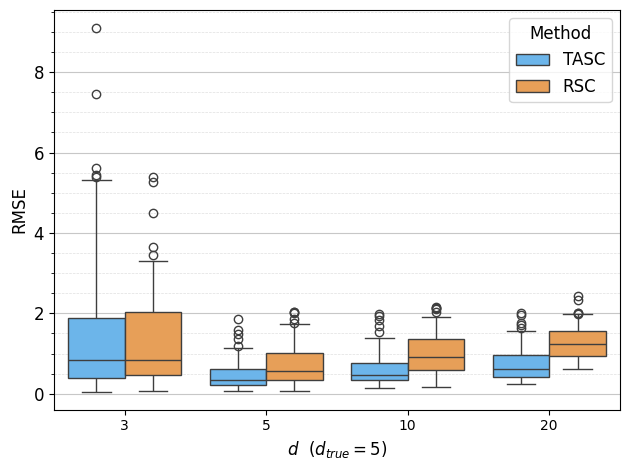

In [6]:
# df_plot = df_long

# xticks = [0, 1]
# xtickers = ["R small, Q small", "R small, Q big"]
font = 12

# plt.figure(figsize=(9, 5))

# ax = sns.violinplot(
ax = sns.boxplot(
    data=df_plot,
    x="d", 
    y="rmse",
    hue="method",
    whis=[0, 95],     
    palette={"TASC": TASC_VColor, "TASC-permuted":TASC_permute_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
    # linewidth=1.5,
    # inner="quartile",
    # cut=0
)

plt.xlabel("$d$  ($d_{true}=5$)", fontsize=font)
plt.ylabel("RMSE", fontsize=font)
# plt.xticks(xticks, xtickers, fontsize=font)
plt.yticks(fontsize=font)
# plt.ylim(bottom=0, top=5)
plt.legend(title="Method", fontsize=font, title_fontsize=font)

# Major + minor gridlines only for y-axis
plt.minorticks_on()
plt.tick_params(axis="x", which="minor", bottom=False, top=False)   # disable x minor ticks
plt.tick_params(axis="y", which="minor", left=True, right=False)     # keep y minor ticks
plt.grid(axis='y', which="major", linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(axis='y', which="minor", linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('exp2_varying_d(d_true=5).png')
plt.show()


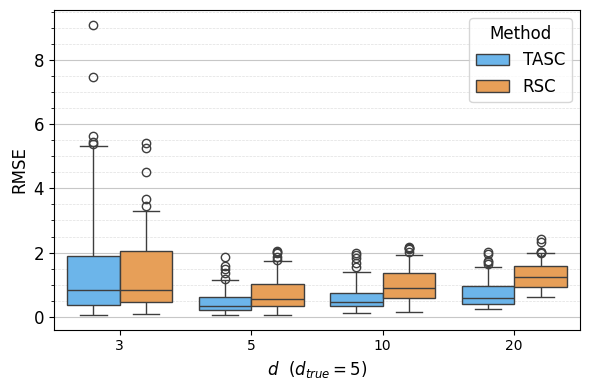

In [7]:
font = 12
plt.figure(figsize=(6, 4))

# ax = sns.violinplot(
ax = sns.boxplot(
    data=df_plot,
    x="d", 
    y="rmse",
    hue="method",
    whis=[0, 95],     
    palette={"TASC": TASC_VColor, "TASC-permuted":TASC_permute_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
    # linewidth=1.5,
    # inner="quartile",
    # cut=0
)

plt.xlabel("$d$  ($d_{true}=5$)", fontsize=font)
plt.ylabel("RMSE", fontsize=font)
# plt.xticks(xticks, xtickers, fontsize=font)
plt.yticks(fontsize=font)
# plt.ylim(bottom=0, top=5)
plt.legend(title="Method", fontsize=font, title_fontsize=font)


# Major + minor gridlines only for y-axis
plt.minorticks_on()
plt.tick_params(axis="x", which="minor", bottom=False, top=False)   # disable x minor ticks
plt.tick_params(axis="y", which="minor", left=True, right=False)     # keep y minor ticks
plt.grid(axis='y', which="major", linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(axis='y', which="minor", linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('exp2_varying_d(d_true=5)_main.png')
plt.show()